# Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score


# Step 2: Create a dataset (with missing values and a categorical column)

In [3]:
data = {
    "YearsExperience": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Education": ["Bachelors", "Masters", "Bachelors", "Masters", "PhD", "Bachelors", "PhD", "Masters", "Bachelors", "Masters"],
    "Salary": [30000, 35000, np.nan, 45000, 50000, 55000, 120000, 65000, 70000, 75000]  # note: NaN + outlier (120000)
}

df = pd.DataFrame(data)
print("Original Dataset:\n", df)

Original Dataset:
    YearsExperience  Education    Salary
0                1  Bachelors   30000.0
1                2    Masters   35000.0
2                3  Bachelors       NaN
3                4    Masters   45000.0
4                5        PhD   50000.0
5                6  Bachelors   55000.0
6                7        PhD  120000.0
7                8    Masters   65000.0
8                9  Bachelors   70000.0
9               10    Masters   75000.0


# Step 3: Exploratory Data Analysis (EDA)


Missing Values:
 YearsExperience    0
Education          0
Salary             1
dtype: int64

Descriptive Statistics:
        YearsExperience         Salary
count         10.00000       9.000000
mean           5.50000   60555.555556
std            3.02765   26977.356760
min            1.00000   30000.000000
25%            3.25000   45000.000000
50%            5.50000   55000.000000
75%            7.75000   70000.000000
max           10.00000  120000.000000


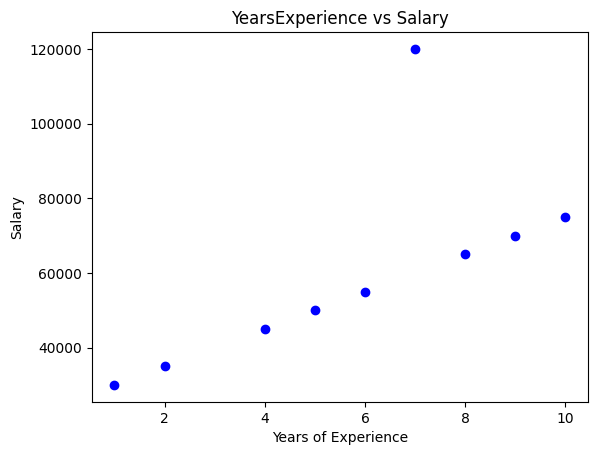

In [4]:
# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Check statistics to find outliers
print("\nDescriptive Statistics:\n", df.describe())

# Visualize
plt.scatter(df["YearsExperience"], df["Salary"], color='blue')
plt.title("YearsExperience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

# Step 4: Data Preprocessing

In [5]:
# 4.1 Handling Missing Values
# Fill missing Salary with median
df["Salary"].fillna(df["Salary"].median(), inplace=True)

# 4.2 Handling Outliers
# For simplicity, we will cap the max salary at 2 standard deviations above mean
mean_salary = df["Salary"].mean()
std_salary = df["Salary"].std()
upper_limit = mean_salary + 2*std_salary
df["Salary"] = np.where(df["Salary"] > upper_limit, upper_limit, df["Salary"])

# 4.3 Encoding Categorical Variables
# Convert Education column to numeric using LabelEncoder
le = LabelEncoder()
df["Education"] = le.fit_transform(df["Education"])  # Bachelors=0, Masters=1, PhD=2

print("\nPreprocessed Dataset:\n", df)

# 4.4 Feature & Target
X = df.drop("Salary", axis=1)  # independent variables
y = df["Salary"]               # dependent variable




Preprocessed Dataset:
    YearsExperience  Education         Salary
0                1          0   30000.000000
1                2          1   35000.000000
2                3          0   55000.000000
3                4          1   45000.000000
4                5          2   50000.000000
5                6          0   55000.000000
6                7          2  110990.195136
7                8          1   65000.000000
8                9          0   70000.000000
9               10          1   75000.000000


C:\Users\hanse\AppData\Local\Temp\ipykernel_22720\3501767190.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Salary"].fillna(df["Salary"].median(), inplace=True)


In [6]:
le.classes_

array(['Bachelors', 'Masters', 'PhD'], dtype=object)

# Step 5: Train/Test Split and Scaling

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Feature Scaling (optional but good practice)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Step 6: Linear Regression Model

In [8]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Step 7: Evaluate Model

In [9]:
print("\nMean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-squared Score:", r2_score(y_test, y_pred))


Mean Squared Error: 72081594.63772985
R-squared Score: 0.7646315277135352


# Step 8: Visualize Regression Line (1 feature for simplicity)

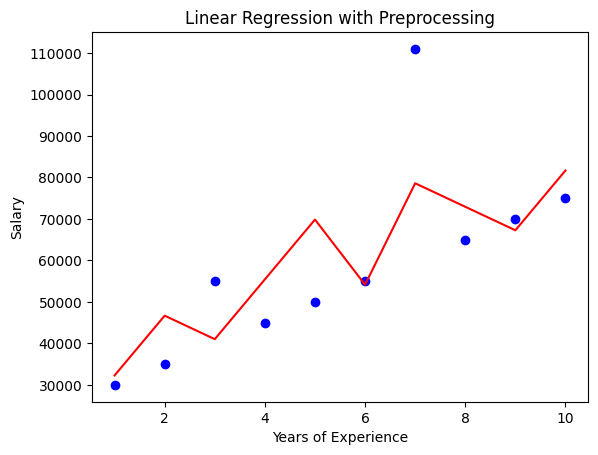

In [10]:
plt.scatter(df["YearsExperience"], df["Salary"], color='blue')
plt.plot(df["YearsExperience"], model.predict(scaler.transform(df[["YearsExperience","Education"]])), color='red')
plt.title("Linear Regression with Preprocessing")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

# Step 9: Predict new salary

In [11]:
new_employee = pd.DataFrame({"YearsExperience":[12], "Education":["PhD"]})
new_employee["Education"] = le.transform(new_employee["Education"])
new_employee_scaled = scaler.transform(new_employee)
predicted_salary = model.predict(new_employee_scaled)
print("\nPredicted salary for 12 years experience with PhD:", predicted_salary[0])


Predicted salary for 12 years experience with PhD: 100473.28235038456
